# 05 - Topic Greenlist Construction

Builds one greenlist per topic (8 topics) from the
`topic_cosine_similarity.csv` produced by notebook 04.


1. **Segregate connector words** (topic-neutral function words like *is, a,
   then*) into a separate list.
2. **Threshold on cosine similarity** (token vs. topic). A token joins the
   greenlist of the topic it is *most* similar to, only if that similarity
   `>= THRESHOLD`. Everything else goes to a redlist.
3. Connector words are kept apart so they can later be **round-robined** into
   each topic's greenlist (cell at the end).
4. **Residual tokens** (non-connectors that fail the threshold for every
   topic, i.e. the redlist) are **also round-robined** into all greenlists,
   so every list covers the whole vocab -> exported to
   `green_list_topics_uniform/<topic>.csv`.

> Note: the paper's detection-time threshold (τ=0.7) applies to a z-score /
> false-positive scale, *not* to token↔topic cosine similarity. On our scale
> token similarities peak around 0.25, so `THRESHOLD` here is a much smaller
> number (default 0.15).

> Verified against `topic_cosine_similarity.csv` (sweep of thresholds):
>
> | THRESHOLD | total green | medicine | entertainment | finance |
> |-----------|------------:|---------:|--------------:|--------:|
> | 0.15      | 17,181 (35%) | 95  | 110 | 102 |
> | 0.18      |  7,117 (14%) | 66  | 53  | 54  |
> | 0.22      |  1,248 (2.5%)| 34  | 22  | 25  |
> | 0.25      |    495 (1%)  | 24  | 15  | 18  |
>
> At ≥0.20 the small topics collapse to a few dozen tokens (unusable for
> watermarking/detection), so 0.15 is kept.

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import os
from collections import defaultdict

import numpy as np
import pandas as pd


DATA_DIR = "/content/drive/MyDrive/minor_project/"
for cand in ("../data/complete/", "data/complete/"):
    if not os.path.isdir(DATA_DIR) and os.path.isfile(
            os.path.join(cand, "topic_cosine_similarity.csv")):
        DATA_DIR = cand
if not os.path.isfile(os.path.join(DATA_DIR, "topic_cosine_similarity.csv")):
    raise FileNotFoundError(f"topic_cosine_similarity.csv not found under {DATA_DIR}")

THRESHOLD = 0.15  

# One greenlist per topic
TOPICS = [
    "technology",
    "medicine",
    "sports",
    "politics",
    "science",
    "entertainment",
    "finance",
    "history",
]
sim_cols = [f"sim_{t}" for t in TOPICS]
print("topics:", TOPICS)

topics: ['technology', 'medicine', 'sports', 'politics', 'science', 'entertainment', 'finance', 'history']


In [46]:

df = pd.read_csv(os.path.join(DATA_DIR, "topic_cosine_similarity.csv")).dropna(subset=["token"])

df["clean"] = df["token"].str.replace("Ġ", "", regex=False).str.lower()

print("rows:", len(df))
print("columns:", list(df.columns))

rows: 50260
columns: ['token_id', 'token', 'sim_technology', 'sim_medicine', 'sim_sports', 'sim_politics', 'sim_science', 'sim_entertainment', 'sim_finance', 'sim_history', 'clean']


In [47]:

CONNECTOR_WORDS = {
    "a", "an", "the",
    "and", "or", "but", "nor", "so", "yet", "for",
    "of", "in", "on", "at", "to", "from", "by", "with", "about",
    "above", "across", "after", "against", "along", "among", "around", "as",
    "before", "behind", "below", "beneath", "beside", "between", "beyond",
    "during", "except", "inside", "into", "near", "off", "onto", "out",
    "outside", "over", "past", "through", "throughout", "till", "toward",
    "under", "until", "up", "upon", "within", "without",
    "is", "are", "was", "were", "be", "been", "being", "am",
    "do", "does", "did", "have", "has", "had",
    "will", "would", "shall", "should", "can", "could", "may", "might", "must",
    "i", "you", "he", "she", "it", "we", "they", "me", "him", "her", "us", "them",
    "my", "your", "his", "its", "our", "their", "mine", "yours", "hers", "ours", "theirs",
    "this", "that", "these", "those", "who", "whom", "whose", "which", "what",
    "whatever", "whoever",
    "then", "than", "if", "unless", "while", "when", "where", "whether", "how", "why",
    "although", "though", "because",
    "not", "no", "only", "just", "very", "also", "too", "such", "here", "there", "now",
    "however", "therefore", "moreover", "furthermore", "nevertheless", "meanwhile",
    "finally", "first", "second", "next", "last", "again",
    "already", "always", "ever", "never", "often", "sometimes", "usually",
    "still", "quite", "rather", "almost", "nearly", "even", "well",
}

conn_mask = df["clean"].isin(CONNECTOR_WORDS)
connectors = df.loc[conn_mask, ["token_id", "token", "clean"]].copy()
main_df = df.loc[~conn_mask].copy()

SPECIAL_TOKENS = {"<s>", "</s>", "<pad>", "<unk>"}
main_df = main_df[~main_df["clean"].isin(SPECIAL_TOKENS)].copy()

print(f"connector words:    {len(connectors):>7}  ({100 * len(connectors) / len(df):.2f}% of vocab)")
print(f"non-connector vocab: {len(main_df):>7}  ({100 * len(main_df) / len(df):.2f}% of vocab)")
print("\nsample connectors:")
print(connectors["token"].head(15).tolist())

connector words:        735  (1.46% of vocab)
non-connector vocab:   49521  (98.53% of vocab)

sample connectors:
['Ġthe', 'Ġto', 'Ġand', 'Ġof', 'Ġa', 'Ġin', 'Ġfor', 'Ġthat', 'Ġon', 'Ġis', 'Ġwith', 'ĠThe', 'Ġwas', 'Ġat', 'Ġit']


In [48]:

best_col = main_df[sim_cols].idxmax(axis=1)
best_sim = main_df[sim_cols].max(axis=1)

main_df["topic"] = best_col.str.replace("sim_", "", regex=False)
main_df["similarity"] = best_sim.round(4)
main_df["greenlist"] = best_sim >= THRESHOLD

print("best-topic assignment counts (all non-connectors):")
print(main_df["topic"].value_counts().to_string())

best-topic assignment counts (all non-connectors):
topic
technology       14313
politics          9826
sports            7465
science           5842
history           5596
entertainment     2598
medicine          2173
finance           1708


In [49]:
greenlists = {}
for t in TOPICS:
    g = main_df[(main_df["topic"] == t) & main_df["greenlist"]]
    greenlists[t] = g["token_id"].tolist()

redlist = main_df[~main_df["greenlist"]]

print(f"threshold: {THRESHOLD}")
print(f"greenlisted tokens: {sum(len(v) for v in greenlists.values()):,}  ({100 * main_df['greenlist'].mean():.1f}% of non-connector vocab)")
print(f"redlist tokens:     {len(redlist):,}")
print("\nper-topic greenlist sizes:")
for t in TOPICS:
    print(f"  {t:15s} {len(greenlists[t]):>7}")

threshold: 0.15
greenlisted tokens: 17,181  (34.7% of non-connector vocab)
redlist tokens:     32,340

per-topic greenlist sizes:
  technology         7105
  medicine             95
  sports             2575
  politics           3566
  science            1958
  entertainment       110
  finance             102
  history            1670


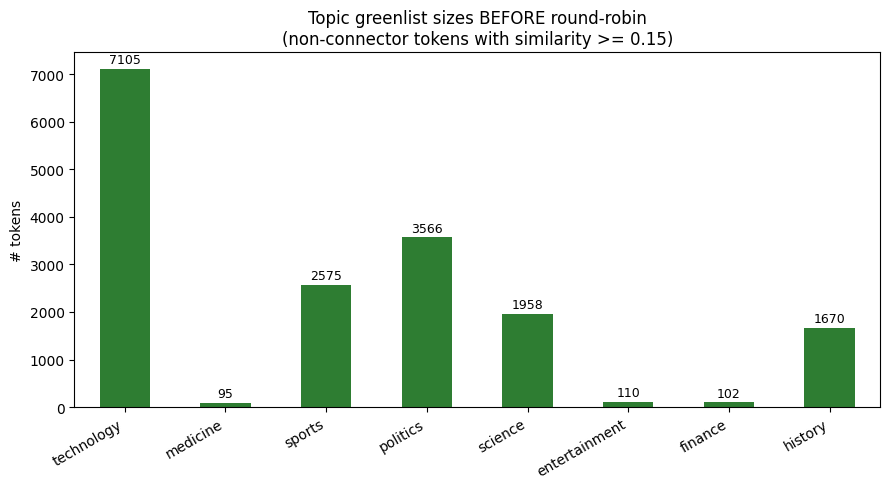

total greenlisted: 17,181 | redlisted (failed threshold): 32,340
technology       7105
medicine           95
sports           2575
politics         3566
science          1958
entertainment     110
finance           102
history          1670


In [50]:
# ------------------------------------------------------------------
# Visualize greenlist sizes BEFORE round-robin
# (only non-connector tokens whose best-topic similarity >= THRESHOLD)
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

gl_sizes = pd.Series({t: len(ids) for t, ids in greenlists.items()},
                     name="greenlist_tokens")

ax = gl_sizes.plot(kind="bar", color="#2e7d32", figsize=(9, 5))
ax.bar_label(ax.containers[0], fmt="%d", padding=2, fontsize=9)
ax.set_title(f"Topic greenlist sizes BEFORE round-robin\n"
             f"(non-connector tokens with similarity >= {THRESHOLD})")
ax.set_ylabel("# tokens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"total greenlisted: {int(gl_sizes.sum()):,} | "
      f"redlisted (failed threshold): {len(redlist):,}")
print(gl_sizes.to_string())

In [51]:
for t in ["technology", "sports"]:
    g = main_df[(main_df["topic"] == t) & main_df["greenlist"]]
    print(f"\n=== greenlist '{t}' (top 20 by similarity) ===")
    print(g.sort_values("similarity", ascending=False)[["token", "similarity"]].head(20).to_string(index=False))


=== greenlist 'technology' (top 20 by similarity) ===
           token  similarity
      technology      1.0000
      Technology      0.7134
     ĠTechnology      0.6306
     Ġtechnology      0.6282
   Ġtechnologies      0.5620
  Ġtechnological      0.5091
           ĠTECH      0.5017
Ġtechnologically      0.4609
            tech      0.4376
     otechnology      0.4127
           Ġtech      0.4063
           techn      0.3922
            Tech      0.3909
   ĠTechnologies      0.3786
       technical      0.3751
         devices      0.3544
           ĠTech      0.3534
        chnology      0.3485
        software      0.3466
         Ġtechno      0.3422

=== greenlist 'sports' (top 20 by similarity) ===
     token  similarity
    sports      1.0000
    Sports      0.6215
   Ġsports      0.5811
   ĠSPORTS      0.5359
   ĠSports      0.5314
     Sport      0.4299
 Ġsporting      0.3919
Ġathletics      0.3774
    Ġsport      0.3736
    ĠSport      0.3725
basketball      0.3530
 Ġathlete

In [52]:

out_dir = os.path.join(DATA_DIR)
os.makedirs(out_dir, exist_ok=True)

rows = []
for t in TOPICS:
    g = main_df[(main_df["topic"] == t) & main_df["greenlist"]]
    rows.append(pd.DataFrame({
        "topic": t,
        "token_id": g["token_id"],
        "token": g["token"],
        "similarity": g["similarity"],
    }))
green_df = pd.concat(rows, ignore_index=True)
green_df.to_csv(os.path.join(out_dir, "topic_greenlists.csv"), index=False)

# Segregated connector words, ready for round-robin distribution
connectors.to_csv(os.path.join(out_dir, "connector_words.csv"), index=False)

print(f"saved topic_greenlists.csv  ({len(green_df):,} rows)")
print(f"saved connector_words.csv   ({len(connectors):,} rows)")
print(green_df.head(5).to_string(index=False))

saved topic_greenlists.csv  (17,181 rows)
saved connector_words.csv   (735 rows)
     topic  token_id       token  similarity
technology       806 Ġtechnology      0.6282
technology      2903       Ġtech      0.4063
technology      3165  Ġtechnical      0.1689
technology      3777 ĠTechnology      0.6306
technology      3815      ĠNIGHT      0.1886


In [53]:
# ------------------------------------------------------------------
# Export one CSV per topic with its greenlist
# ------------------------------------------------------------------
per_topic_dir = os.path.join(DATA_DIR, "greenlists_topics")
os.makedirs(per_topic_dir, exist_ok=True)

for t in TOPICS:
    g = main_df[(main_df["topic"] == t) & main_df["greenlist"]].sort_values(
        "similarity", ascending=False)
    path = os.path.join(per_topic_dir, f"{t}_list.csv")
    g[["token_id", "token", "similarity"]].to_csv(path, index=False)
    print(f"saved {path}  ({len(g):,} tokens)")

# Connector words are NOT discarded: saved alongside so they can be
# round-robined into the greenlists later.
conn_path = os.path.join(per_topic_dir, "connector_words.csv")
connectors.to_csv(conn_path, index=False)
print(f"saved {conn_path}  ({len(connectors):,} connectors)")

saved /content/drive/MyDrive/minor_project/greenlists_topics/technology_list.csv  (7,105 tokens)
saved /content/drive/MyDrive/minor_project/greenlists_topics/medicine_list.csv  (95 tokens)
saved /content/drive/MyDrive/minor_project/greenlists_topics/sports_list.csv  (2,575 tokens)
saved /content/drive/MyDrive/minor_project/greenlists_topics/politics_list.csv  (3,566 tokens)
saved /content/drive/MyDrive/minor_project/greenlists_topics/science_list.csv  (1,958 tokens)
saved /content/drive/MyDrive/minor_project/greenlists_topics/entertainment_list.csv  (110 tokens)
saved /content/drive/MyDrive/minor_project/greenlists_topics/finance_list.csv  (102 tokens)
saved /content/drive/MyDrive/minor_project/greenlists_topics/history_list.csv  (1,670 tokens)
saved /content/drive/MyDrive/minor_project/greenlists_topics/connector_words.csv  (735 connectors)


In [54]:
# Distributes the segregated connector tokens evenly across the 8 greenlists
# so that topic-greenlist keys are available even when the model emits a
# connector word mid-sentence.
def round_robin_connectors(greenlists, connector_ids):
    # Return a copy of greenlists with connectors distributed evenly
    # across the topic greenlists.
    topics = list(greenlists)
    out = {t: list(ids) for t, ids in greenlists.items()}
    for i, tid in enumerate(connector_ids):
        out[topics[i % len(topics)]].append(tid)
    return out

# Example: with_connectors = round_robin_connectors(greenlists, connectors["token_id"].tolist())
print("round_robin_connectors() defined — call it when you want to fold",
      "connector words into the per-topic greenlists.")

round_robin_connectors() defined — call it when you want to fold connector words into the per-topic greenlists.


In [55]:
round_robin_greenlists = round_robin_connectors(greenlists, connectors["token_id"].tolist())

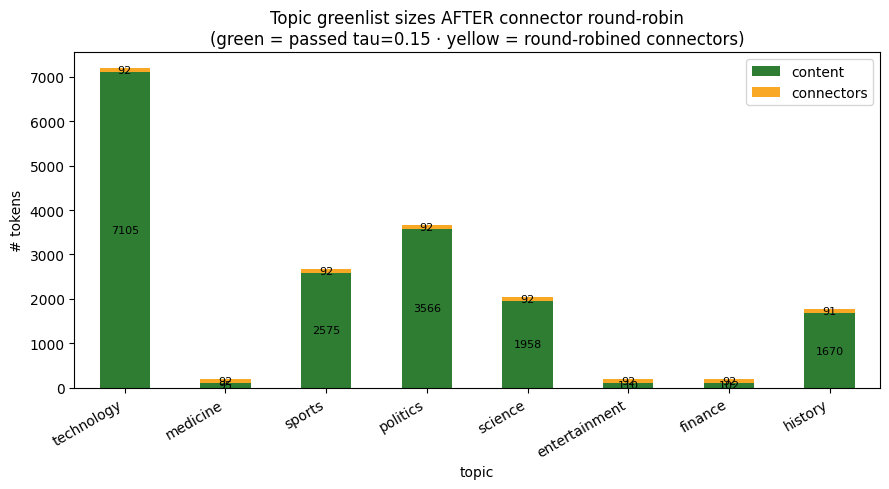

               content  connectors  total
topic                                    
technology        7105          92   7197
medicine            95          92    187
sports            2575          92   2667
politics          3566          92   3658
science           1958          92   2050
entertainment      110          92    202
finance            102          92    194
history           1670          91   1761


In [56]:
# ------------------------------------------------------------------
# Visualize greenlist sizes AFTER connector round-robin
# (stacked: content tokens vs evenly distributed connector words)
# ------------------------------------------------------------------
conn_ids = set(connectors["token_id"].tolist())

rows = []
for t in TOPICS:
    ids = round_robin_greenlists[t]
    n_conn = sum(1 for tid in ids if tid in conn_ids)
    rows.append({"topic": t,
                 "content": len(ids) - n_conn,
                 "connectors": n_conn,
                 "total": len(ids)})
rr_df = pd.DataFrame(rows).set_index("topic")

ax = rr_df[["content", "connectors"]].plot(
    kind="bar", stacked=True, figsize=(9, 5),
    color=["#2e7d32", "#f9a825"])
for container in ax.containers:
    ax.bar_label(container, label_type="center", fontsize=8, fmt="%d")
ax.set_title("Topic greenlist sizes AFTER connector round-robin\n"
             f"(green = passed tau={THRESHOLD} · yellow = round-robined connectors)")
ax.set_ylabel("# tokens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(rr_df.to_string())

In [ ]:

residual_ids = redlist["token_id"].tolist()
uniform_greenlists = round_robin_connectors(round_robin_greenlists, residual_ids)

n_content  = int(main_df["greenlist"].sum())
n_conn     = len(connectors)
print(f"content tokens (passed tau={THRESHOLD}): {n_content:,}")
print(f"connector tokens (round-robined):       {n_conn:,}")
print(f"residual tokens (round-robined):        {len(residual_ids):,}")
assert sum(len(v) for v in uniform_greenlists.values()) == n_content + n_conn + len(residual_ids)
print("\nfinal uniform list sizes:")
for t in TOPICS:
    print(f"  {t:15s} {len(uniform_greenlists[t]):>7}")

content tokens (passed tau=0.15): 17,181
connector tokens (round-robined):       735
residual tokens (round-robined):        32,340

final uniform list sizes:
  technology        11240
  medicine           4230
  sports             6710
  politics           7701
  science            6092
  entertainment      4244
  finance            4236
  history            5803


In [60]:
# ------------------------------------------------------------------
# Export UNIFORM lists: content (passed tau) + connectors + residuals.
# One CSV per topic -> DATA_DIR/green_list_topics_uniform/<topic>.csv
# 'type' column marks each row; 'similarity' is empty for connectors
# and keeps the below-threshold value for residual tokens.
# ------------------------------------------------------------------
uniform_dir = os.path.join(DATA_DIR, "green_list_topics_uniform")
os.makedirs(uniform_dir, exist_ok=True)

token_lookup = dict(zip(df["token_id"], df["token"]))
sim_lookup   = dict(zip(main_df["token_id"], main_df["similarity"]))
conn_set     = set(connectors["token_id"])
content_set  = set(main_df.loc[main_df["greenlist"], "token_id"])

for t in TOPICS:
    ids = uniform_greenlists[t]
    types = ["connector" if i in conn_set else
             "content"   if i in content_set else "residual" for i in ids]
    out = pd.DataFrame({
        "token_id":   ids,
        "token":      [token_lookup[i] for i in ids],
        "similarity": [sim_lookup.get(i, "") for i in ids],
        "type":       types,
    })
    path_t = os.path.join(uniform_dir, f"{t}.csv")
    out.to_csv(path_t, index=False)
    print(f"saved {path_t}  ({len(out):,} tokens)")

saved /content/drive/MyDrive/minor_project/green_list_topics_uniform/technology.csv  (11,240 tokens)
saved /content/drive/MyDrive/minor_project/green_list_topics_uniform/medicine.csv  (4,230 tokens)
saved /content/drive/MyDrive/minor_project/green_list_topics_uniform/sports.csv  (6,710 tokens)
saved /content/drive/MyDrive/minor_project/green_list_topics_uniform/politics.csv  (7,701 tokens)
saved /content/drive/MyDrive/minor_project/green_list_topics_uniform/science.csv  (6,092 tokens)
saved /content/drive/MyDrive/minor_project/green_list_topics_uniform/entertainment.csv  (4,244 tokens)
saved /content/drive/MyDrive/minor_project/green_list_topics_uniform/finance.csv  (4,236 tokens)
saved /content/drive/MyDrive/minor_project/green_list_topics_uniform/history.csv  (5,803 tokens)


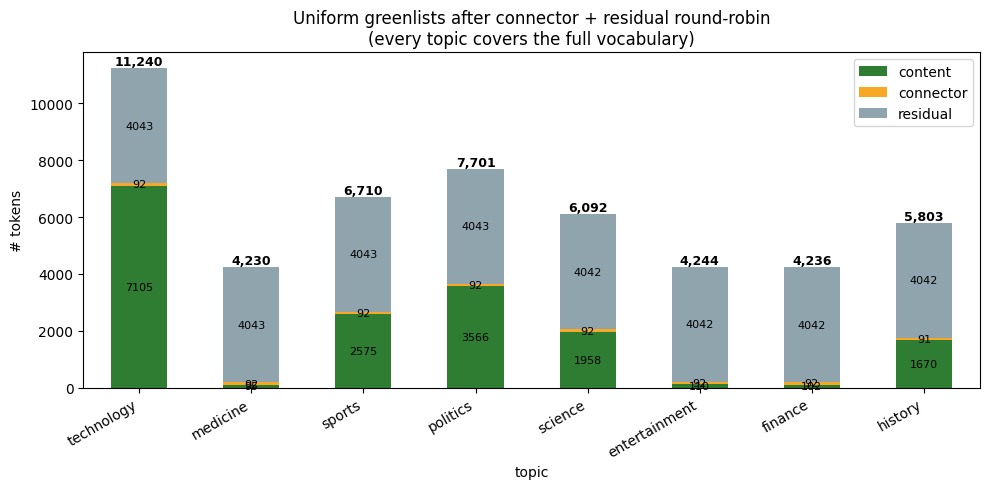

               content  connector  residual  total
topic                                             
technology        7105         92      4043  11240
medicine            95         92      4043   4230
sports            2575         92      4043   6710
politics          3566         92      4043   7701
science           1958         92      4042   6092
entertainment      110         92      4042   4244
finance            102         92      4042   4236
history           1670         91      4042   5803


In [ ]:

conn_set    = set(connectors["token_id"])
content_set = set(main_df.loc[main_df["greenlist"], "token_id"])

rows = []
for t in TOPICS:
    ids = uniform_greenlists[t]
    rows.append({
        "topic": t,
        "content":   sum(1 for i in ids if i in content_set),
        "connector": sum(1 for i in ids if i in conn_set),
        "residual":  len(ids) - sum(1 for i in ids if i in content_set) - sum(1 for i in ids if i in conn_set),
        "total":     len(ids),
    })
uni_df = pd.DataFrame(rows).set_index("topic")

ax = uni_df[["content", "connector", "residual"]].plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=["#2e7d32", "#f9a825", "#90a4ae"])
for container in ax.containers:
    ax.bar_label(container, label_type="center", fontsize=8, fmt="%d")
for x, total in enumerate(uni_df["total"]):
    ax.text(x, total, f"{total:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Uniform greenlists after connector + residual round-robin\n"
             "(every topic covers the full vocabulary)")
ax.set_ylabel("# tokens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(uni_df.to_string())